# Proyek UAS PBA - ABSA Multilabel Text Classification dan NER

Notebook ini digunakan untuk membaca, memvalidasi, dan memahami struktur dataset hasil anotasi ABSA dari proyek UTS. Dataset utama berasal dari file JSONL hasil Prodigy yang memuat teks review, label multilabel, token, dan span/entity.

In [19]:
import json
import re
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    accuracy_score,
    multilabel_confusion_matrix
)

### Path Dataset dan Folder Output

In [20]:
DATA_PATH = "../dataset/Kelp4_dataset_anotasi.jsonl"

DATASET_DIR = "../dataset"
MODEL_DIR = "../models"

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Dataset path:", DATA_PATH)
print("Model dir:", MODEL_DIR)

Dataset path: ../dataset/Kelp4_dataset_anotasi.jsonl
Model dir: ../models


### Load Dataset JSONL

In [21]:
data = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

print("Jumlah data awal:", len(data))

Jumlah data awal: 2118


### Ubah ke DataFrame

In [22]:
df = pd.DataFrame(data)

print("Kolom dataset:")
print(df.columns.tolist())

df.head()

Kolom dataset:
['text', 'tokens', 'spans', '_input_hash', '_task_hash', 'options', '_view_id', 'accept', 'config', 'answer', '_timestamp', '_annotator_id', '_session_id']


,text,tokens,spans,_input_hash,_task_hash,options,_view_id,accept,config,answer,_timestamp,_annotator_id,_session_id
0,Semuanya worth bakso mozanya enak banget,"[{'text': 'Semuanya', 'start': 0, 'end': 8, 'i...","[{'start': 0, 'end': 40, 'token_start': 0, 'to...",-832848900,-485476066,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[PRODUCT_POSITIVE],{'choice_style': 'multiple'},accept,1776436180,nlp4_genap2526-230712427,nlp4_genap2526-230712427
1,Bakso bakar ya enak dan pas,"[{'text': 'Bakso', 'start': 0, 'end': 5, 'id':...","[{'start': 0, 'end': 27, 'token_start': 0, 'to...",616756199,-494867163,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[PRODUCT_POSITIVE],{'choice_style': 'multiple'},accept,1776436292,nlp4_genap2526-230712427,nlp4_genap2526-230712427
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[{'text': 'Saya', 'start': 0, 'end': 4, 'id': ...","[{'start': 41, 'end': 75, 'token_start': 8, 't...",-1099850682,-1708591340,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,"[PRODUCT_NEGATIVE, OUT_OF_TOPIC, PLACE_NEGATIVE]",{'choice_style': 'multiple'},accept,1776436302,nlp4_genap2526-230712427,nlp4_genap2526-230712427
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[{'text': 'Ud', 'start': 0, 'end': 2, 'id': 0,...","[{'start': 0, 'end': 23, 'token_start': 0, 'to...",1518700474,1889327892,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,"[OUT_OF_TOPIC, PLACE_NEGATIVE, PRODUCT_POSITIVE]",{'choice_style': 'multiple'},accept,1776436337,nlp4_genap2526-230712427,nlp4_genap2526-230712427
4,"servisnya oke banget. baru dateng, mba pelayan...","[{'text': 'servisnya', 'start': 0, 'end': 9, '...","[{'start': 0, 'end': 20, 'token_start': 0, 'to...",1104821067,-1778492930,"[{'id': 'PRODUCT_POSITIVE', 'text': 'PRODUCT_P...",blocks,[OUT_OF_TOPIC],{'choice_style': 'multiple'},accept,1776436409,nlp4_genap2526-230712427,nlp4_genap2526-230712427


### Validasi Kolom Dataset

In [23]:
required_columns = ["text", "accept", "spans", "tokens", "answer"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) == 0:
    print("Semua kolom wajib tersedia.")
else:
    print("Kolom yang hilang:", missing_columns)

Semua kolom wajib tersedia.


### Ambil Kolom Utama

In [24]:
df_main = df[["text", "accept", "spans", "tokens", "answer"]].copy()

print("Shape df_main:", df_main.shape)
df_main.head()

Shape df_main: (2118, 5)


,text,accept,spans,tokens,answer
0,Semuanya worth bakso mozanya enak banget,[PRODUCT_POSITIVE],"[{'start': 0, 'end': 40, 'token_start': 0, 'to...","[{'text': 'Semuanya', 'start': 0, 'end': 8, 'i...",accept
1,Bakso bakar ya enak dan pas,[PRODUCT_POSITIVE],"[{'start': 0, 'end': 27, 'token_start': 0, 'to...","[{'text': 'Bakso', 'start': 0, 'end': 5, 'id':...",accept
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[PRODUCT_NEGATIVE, OUT_OF_TOPIC, PLACE_NEGATIVE]","[{'start': 41, 'end': 75, 'token_start': 8, 't...","[{'text': 'Saya', 'start': 0, 'end': 4, 'id': ...",accept
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[OUT_OF_TOPIC, PLACE_NEGATIVE, PRODUCT_POSITIVE]","[{'start': 0, 'end': 23, 'token_start': 0, 'to...","[{'text': 'Ud', 'start': 0, 'end': 2, 'id': 0,...",accept
4,"servisnya oke banget. baru dateng, mba pelayan...",[OUT_OF_TOPIC],"[{'start': 0, 'end': 20, 'token_start': 0, 'to...","[{'text': 'servisnya', 'start': 0, 'end': 9, '...",accept


### Validasi Status Anotasi

In [25]:
print("Distribusi kolom answer:")
print(df_main["answer"].value_counts(dropna=False))

Distribusi kolom answer:
answer
accept    2117
ignore       1
Name: count, dtype: int64


### Filter Data Accept

In [26]:
df_main = df_main[df_main["answer"] == "accept"].copy()
df_main = df_main.reset_index(drop=True)

print("Jumlah data dengan answer accept:", len(df_main))
df_main.head()

Jumlah data dengan answer accept: 2117


,text,accept,spans,tokens,answer
0,Semuanya worth bakso mozanya enak banget,[PRODUCT_POSITIVE],"[{'start': 0, 'end': 40, 'token_start': 0, 'to...","[{'text': 'Semuanya', 'start': 0, 'end': 8, 'i...",accept
1,Bakso bakar ya enak dan pas,[PRODUCT_POSITIVE],"[{'start': 0, 'end': 27, 'token_start': 0, 'to...","[{'text': 'Bakso', 'start': 0, 'end': 5, 'id':...",accept
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[PRODUCT_NEGATIVE, OUT_OF_TOPIC, PLACE_NEGATIVE]","[{'start': 41, 'end': 75, 'token_start': 8, 't...","[{'text': 'Saya', 'start': 0, 'end': 4, 'id': ...",accept
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[OUT_OF_TOPIC, PLACE_NEGATIVE, PRODUCT_POSITIVE]","[{'start': 0, 'end': 23, 'token_start': 0, 'to...","[{'text': 'Ud', 'start': 0, 'end': 2, 'id': 0,...",accept
4,"servisnya oke banget. baru dateng, mba pelayan...",[OUT_OF_TOPIC],"[{'start': 0, 'end': 20, 'token_start': 0, 'to...","[{'text': 'servisnya', 'start': 0, 'end': 9, '...",accept


### Validasi Teks Kosong

In [27]:
df_main["text"] = df_main["text"].astype(str)

empty_text = df_main[df_main["text"].str.strip() == ""]

print("Jumlah teks kosong:", len(empty_text))

Jumlah teks kosong: 0


### Daftar Label Multilabel

In [28]:
MULTILABEL_COLUMNS = [
    "PRODUCT_POSITIVE",
    "PRODUCT_NEGATIVE",
    "PRODUCT_NEUTRAL",
    "PRICE_POSITIVE",
    "PRICE_NEGATIVE",
    "PRICE_NEUTRAL",
    "PLACE_POSITIVE",
    "PLACE_NEGATIVE",
    "PLACE_NEUTRAL",
    "PROMOTION_POSITIVE",
    "PROMOTION_NEGATIVE",
    "PROMOTION_NEUTRAL",
    "OUT_OF_TOPIC"
]

print("Jumlah label:", len(MULTILABEL_COLUMNS))
MULTILABEL_COLUMNS

Jumlah label: 13


['PRODUCT_POSITIVE',
 'PRODUCT_NEGATIVE',
 'PRODUCT_NEUTRAL',
 'PRICE_POSITIVE',
 'PRICE_NEGATIVE',
 'PRICE_NEUTRAL',
 'PLACE_POSITIVE',
 'PLACE_NEGATIVE',
 'PLACE_NEUTRAL',
 'PROMOTION_POSITIVE',
 'PROMOTION_NEGATIVE',
 'PROMOTION_NEUTRAL',
 'OUT_OF_TOPIC']

### Encoding Label Multilabel

In [29]:
df_multilabel = pd.DataFrame()
df_multilabel["text"] = df_main["text"].astype(str)
df_multilabel["labels"] = df_main["accept"]

for label in MULTILABEL_COLUMNS:
    df_multilabel[label] = df_multilabel["labels"].apply(
        lambda x: 1 if label in x else 0
    )

df_multilabel["jumlah_label"] = df_multilabel[MULTILABEL_COLUMNS].sum(axis=1)

print("Shape df_multilabel:", df_multilabel.shape)
df_multilabel.head()

Shape df_multilabel: (2117, 16)


,text,labels,PRODUCT_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRICE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PLACE_POSITIVE,PLACE_NEGATIVE,PLACE_NEUTRAL,PROMOTION_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,OUT_OF_TOPIC,jumlah_label
0,Semuanya worth bakso mozanya enak banget,[PRODUCT_POSITIVE],1,0,0,0,0,0,0,0,0,0,0,0,0,1
1,Bakso bakar ya enak dan pas,[PRODUCT_POSITIVE],1,0,0,0,0,0,0,0,0,0,0,0,0,1
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...","[PRODUCT_NEGATIVE, OUT_OF_TOPIC, PLACE_NEGATIVE]",0,1,0,0,0,0,0,1,0,0,0,0,1,3
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...","[OUT_OF_TOPIC, PLACE_NEGATIVE, PRODUCT_POSITIVE]",1,0,0,0,0,0,0,1,0,0,0,0,1,3
4,"servisnya oke banget. baru dateng, mba pelayan...",[OUT_OF_TOPIC],0,0,0,0,0,0,0,0,0,0,0,0,1,1


### Cek Data Tanpa Label

In [30]:
invalid_no_label = df_multilabel[df_multilabel["jumlah_label"] == 0].copy()

print("Jumlah data tanpa label:", len(invalid_no_label))

if len(invalid_no_label) > 0:
    invalid_no_label.to_csv(
        "../dataset/Kelp4_invalid_no_label.csv",
        index=False
    )

df_multilabel[df_multilabel["jumlah_label"] == 0].head()

Jumlah data tanpa label: 14


,text,labels,PRODUCT_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRICE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PLACE_POSITIVE,PLACE_NEGATIVE,PLACE_NEUTRAL,PROMOTION_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,OUT_OF_TOPIC,jumlah_label
173,Baksonya enak. The best in Jogja.,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0
351,Akan lebih menarik apabila ada smoking area,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0
511,Tidak direkomendasikan kalau kesabaran anda se...,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0
524,Hari ini pelayanan untuk saya sendiri kurang m...,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0
881,Yang liburan ke Jogja wajib cobain bakso ini,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Hapus Data Tanpa Label

In [31]:
valid_index = df_multilabel[df_multilabel["jumlah_label"] > 0].index

df_multilabel = df_multilabel.loc[valid_index].reset_index(drop=True)
df_main = df_main.loc[valid_index].reset_index(drop=True)

print("Jumlah data setelah menghapus data tanpa label:", len(df_multilabel))
print("Shape df_multilabel:", df_multilabel.shape)
print("Shape df_main:", df_main.shape)

Jumlah data setelah menghapus data tanpa label: 2103
Shape df_multilabel: (2103, 16)
Shape df_main: (2103, 5)


### Distribusi Label

In [32]:
label_distribution = df_multilabel[MULTILABEL_COLUMNS].sum()
label_distribution = label_distribution.sort_values(ascending=False)

label_distribution_df = label_distribution.reset_index()
label_distribution_df.columns = ["label", "jumlah"]

label_distribution_df

,label,jumlah
0,PRODUCT_POSITIVE,1641
1,OUT_OF_TOPIC,698
2,PLACE_POSITIVE,537
3,PROMOTION_POSITIVE,290
4,PRODUCT_NEGATIVE,242
5,PLACE_NEGATIVE,192
6,PRICE_POSITIVE,181
7,PROMOTION_NEGATIVE,131
8,PRODUCT_NEUTRAL,113
9,PRICE_NEGATIVE,43


### Visualisasi Distribusi Label ABSA

In [33]:
label_distribution = df_multilabel[MULTILABEL_COLUMNS].sum()
label_distribution = label_distribution.sort_values(ascending=False)

label_distribution_df = label_distribution.reset_index()
label_distribution_df.columns = ["label", "jumlah"]

label_distribution_df

,label,jumlah
0,PRODUCT_POSITIVE,1641
1,OUT_OF_TOPIC,698
2,PLACE_POSITIVE,537
3,PROMOTION_POSITIVE,290
4,PRODUCT_NEGATIVE,242
5,PLACE_NEGATIVE,192
6,PRICE_POSITIVE,181
7,PROMOTION_NEGATIVE,131
8,PRODUCT_NEUTRAL,113
9,PRICE_NEGATIVE,43


### EDA Panjang Review

In [34]:
df_multilabel["panjang_karakter"] = df_multilabel["text"].apply(len)
df_multilabel["jumlah_kata"] = df_multilabel["text"].apply(
    lambda x: len(str(x).split())
)

df_multilabel[["panjang_karakter", "jumlah_kata"]].describe()

,panjang_karakter,jumlah_kata
count,2103.000000,2103.000000
mean,145.858773,22.941037
std,184.434803,29.447890
min,22.000000,5.000000
25%,49.000000,7.000000
50%,80.000000,12.000000
75%,157.000000,25.000000
max,1687.000000,276.000000


### Visualisasi Distribusi Panjang Review

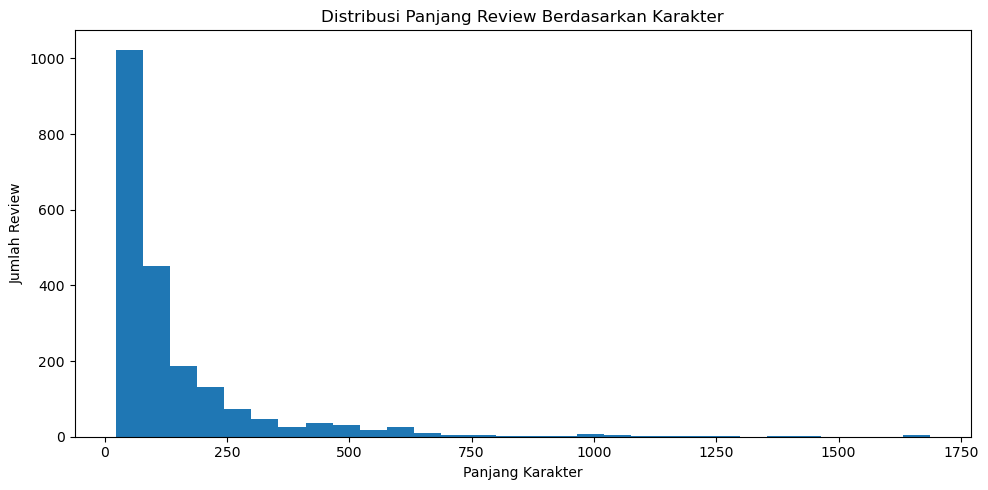

In [35]:
plt.figure(figsize=(10, 5))
plt.hist(df_multilabel["panjang_karakter"], bins=30)
plt.xlabel("Panjang Karakter")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Panjang Review Berdasarkan Karakter")
plt.tight_layout()
plt.show()

### Visualisasi Distribusi Jumlah Kata

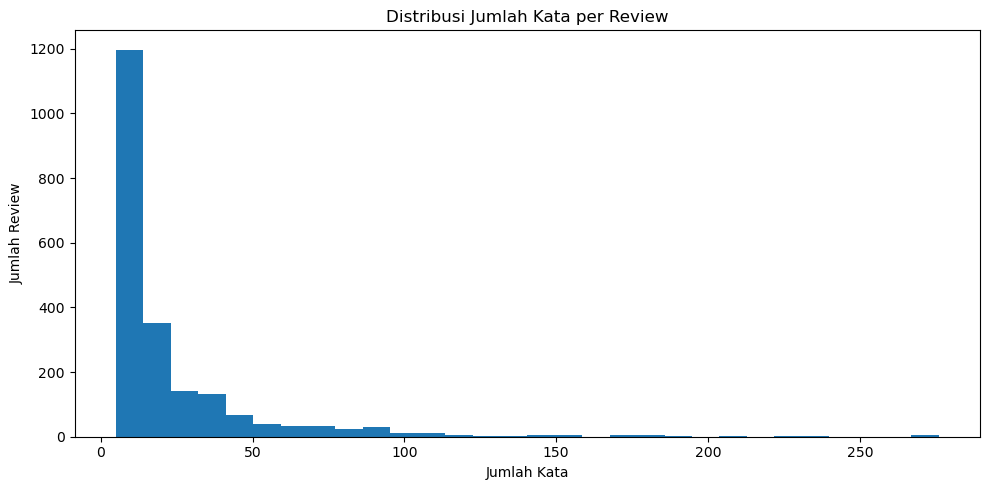

In [36]:
plt.figure(figsize=(10, 5))
plt.hist(df_multilabel["jumlah_kata"], bins=30)
plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Jumlah Kata per Review")
plt.tight_layout()
plt.show()

### Distribusi Jumlah Label per Review

In [37]:
jumlah_label_distribution = df_multilabel["jumlah_label"].value_counts().sort_index()

jumlah_label_distribution

jumlah_label
1    841
2    715
3    391
4    112
5     33
6     10
7      1
Name: count, dtype: int64

### Visualisasi Jumlah Label per Review

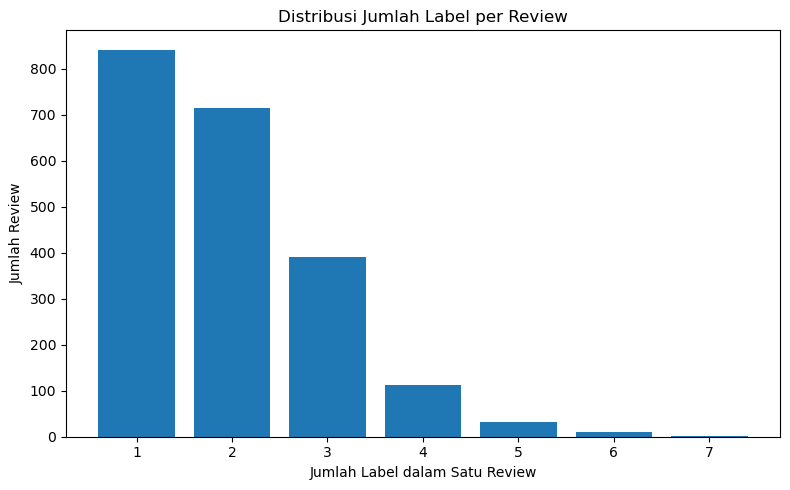

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(
    jumlah_label_distribution.index.astype(str),
    jumlah_label_distribution.values
)
plt.xlabel("Jumlah Label dalam Satu Review")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Jumlah Label per Review")
plt.tight_layout()
plt.show()

### Correlation Matrix Antar Label

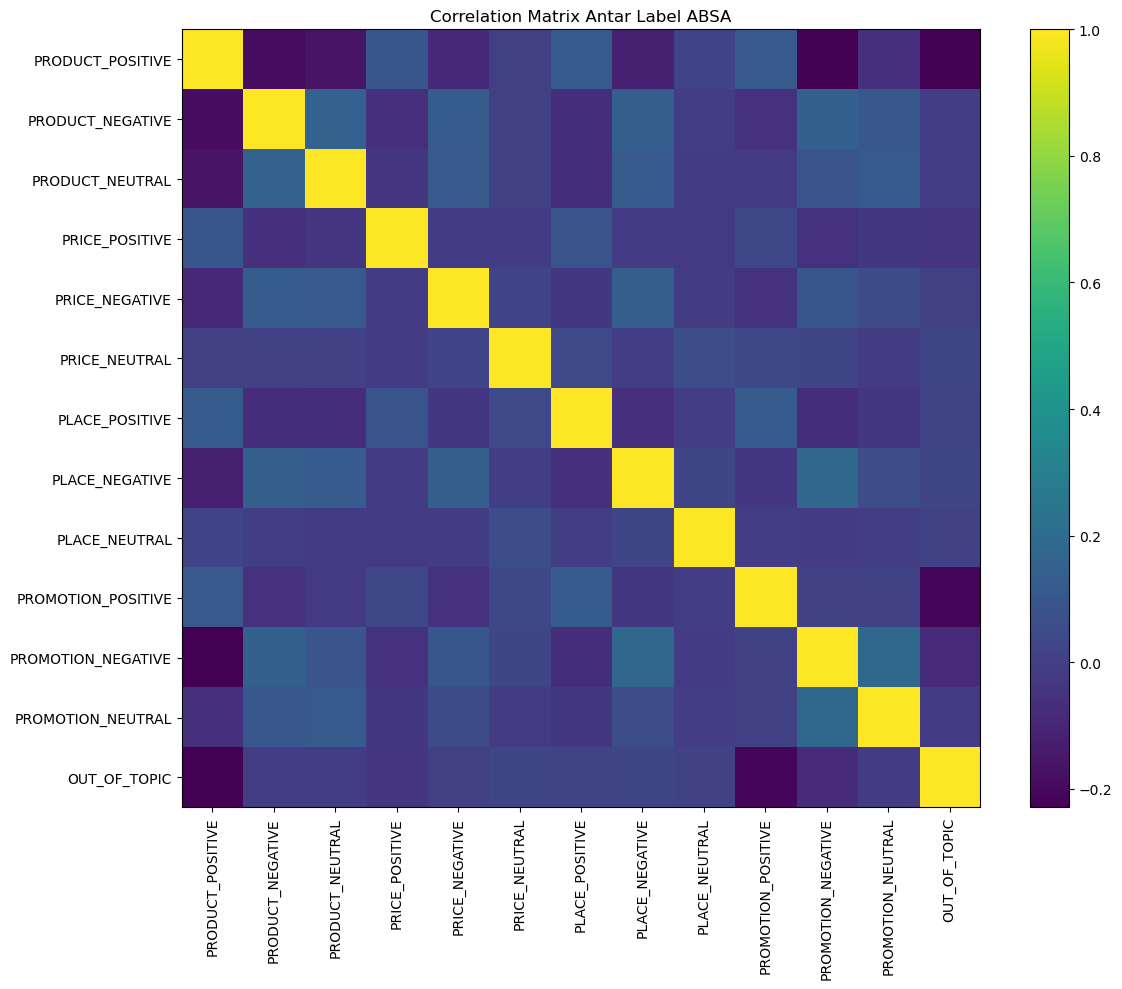

,PRODUCT_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRICE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PLACE_POSITIVE,PLACE_NEGATIVE,PLACE_NEUTRAL,PROMOTION_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,OUT_OF_TOPIC
PRODUCT_POSITIVE,1.000000,-0.190157,-0.163879,0.101404,-0.085643,0.002946,0.121079,-0.118903,0.017192,0.115613,-0.229146,-0.065672,-0.225988
PRODUCT_NEGATIVE,-0.190157,1.000000,0.158578,-0.057531,0.126895,0.003342,-0.067643,0.144369,-0.000814,-0.053466,0.147512,0.105353,-0.007346
PRODUCT_NEUTRAL,-0.163879,0.158578,1.000000,-0.035532,0.114579,0.014104,-0.067001,0.122145,-0.015622,-0.021911,0.095639,0.116873,-0.006742
PRICE_POSITIVE,0.101404,-0.057531,-0.035532,1.000000,-0.008397,-0.017010,0.092466,-0.014863,-0.020118,0.039537,-0.051034,-0.032270,-0.036275
PRICE_NEGATIVE,-0.085643,0.126895,0.114579,-0.008397,1.000000,0.016110,-0.030667,0.140847,-0.009472,-0.048038,0.101784,0.049418,0.005194
PRICE_NEUTRAL,0.002946,0.003342,0.014104,-0.017010,0.016110,1.000000,0.039748,-0.002971,0.061536,0.034933,0.027877,-0.011298,0.028846
PLACE_POSITIVE,0.121079,-0.067643,-0.067001,0.092466,-0.030667,0.039748,1.000000,-0.060678,-0.004981,0.129508,-0.069714,-0.030123,0.022616
PLACE_NEGATIVE,-0.118903,0.144369,0.122145,-0.014863,0.140847,-0.002971,-0.060678,1.000000,0.029800,-0.031010,0.177873,0.061907,0.025501
PLACE_NEUTRAL,0.017192,-0.000814,-0.015622,-0.020118,-0.009472,0.061536,-0.004981,0.029800,1.000000,-0.005093,-0.016897,-0.006894,0.015668
PROMOTION_POSITIVE,0.115613,-0.053466,-0.021911,0.039537,-0.048038,0.034933,0.129508,-0.031010,-0.005093,1.000000,0.011044,0.010984,-0.214536


In [39]:
label_corr = df_multilabel[MULTILABEL_COLUMNS].corr()

plt.figure(figsize=(12, 10))
plt.imshow(label_corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(MULTILABEL_COLUMNS)), MULTILABEL_COLUMNS, rotation=90)
plt.yticks(range(len(MULTILABEL_COLUMNS)), MULTILABEL_COLUMNS)
plt.title("Correlation Matrix Antar Label ABSA")
plt.tight_layout()
plt.show()

label_corr

### Fungsi Cleaning Text dengan Negation Handling

In [40]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    tokens = text.split()
    
    negation_words = {
        "tidak", "tdk", "nggak", "ngga", "gak", "ga",
        "kurang", "tak", "bukan"
    }
    
    new_tokens = []
    i = 0
    
    while i < len(tokens):
        token = tokens[i]
        
        if token in negation_words and i + 1 < len(tokens):
            next_token = tokens[i + 1]
            new_tokens.append(token)
            new_tokens.append(token + "_" + next_token)
            i += 2
        else:
            new_tokens.append(token)
            i += 1
    
    return " ".join(new_tokens)

### Contoh Cleaning

In [41]:
contoh = "Baksonya tidak enak, tapi tempatnya luas!"
print("Teks asli:", contoh)
print("Teks clean:", clean_text(contoh))

Teks asli: Baksonya tidak enak, tapi tempatnya luas!
Teks clean: baksonya tidak tidak_enak tapi tempatnya luas


### Siapkan Data Final Multilabel

In [42]:
df_multilabel_final = df_multilabel[["text"] + MULTILABEL_COLUMNS].copy()

print("Shape df_multilabel_final:", df_multilabel_final.shape)
df_multilabel_final.head()

Shape df_multilabel_final: (2103, 14)


,text,PRODUCT_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRICE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PLACE_POSITIVE,PLACE_NEGATIVE,PLACE_NEUTRAL,PROMOTION_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,OUT_OF_TOPIC
0,Semuanya worth bakso mozanya enak banget,1,0,0,0,0,0,0,0,0,0,0,0,0
1,Bakso bakar ya enak dan pas,1,0,0,0,0,0,0,0,0,0,0,0,0
2,"Saya kesini jam 3 sore bersama keluarga, yg sa...",0,1,0,0,0,0,0,1,0,0,0,0,1
3,"Ud 3x ksni tiap k jogja, baksonya enak, saran ...",1,0,0,0,0,0,0,1,0,0,0,0,1
4,"servisnya oke banget. baru dateng, mba pelayan...",0,0,0,0,0,0,0,0,0,0,0,0,1


### Split Train Validation Test

In [43]:
train_df, temp_df = train_test_split(
    df_multilabel_final,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1682, 14)
Validation: (210, 14)
Test: (211, 14)


### Cek Distribusi Label Tiap Split

In [44]:
split_distribution = pd.DataFrame({
    "train": train_df[MULTILABEL_COLUMNS].sum(),
    "validation": val_df[MULTILABEL_COLUMNS].sum(),
    "test": test_df[MULTILABEL_COLUMNS].sum()
})

split_distribution

,train,validation,test
PRODUCT_POSITIVE,1295,174,172
PRODUCT_NEGATIVE,200,18,24
PRODUCT_NEUTRAL,94,4,15
PRICE_POSITIVE,142,18,21
PRICE_NEGATIVE,35,4,4
PRICE_NEUTRAL,16,6,2
PLACE_POSITIVE,431,54,52
PLACE_NEGATIVE,157,16,19
PLACE_NEUTRAL,8,1,0
PROMOTION_POSITIVE,232,29,29


### Simpan Split Dataset

In [45]:
train_df.to_csv("../dataset/Kelp4_multilabel_train.csv", index=False)
val_df.to_csv("../dataset/Kelp4_multilabel_val.csv", index=False)
test_df.to_csv("../dataset/Kelp4_multilabel_test.csv", index=False)

print("Dataset split multilabel berhasil disimpan.")

Dataset split multilabel berhasil disimpan.


### Apply Cleaning untuk Modeling

In [46]:
train_df["text_clean"] = train_df["text"].apply(clean_text)
val_df["text_clean"] = val_df["text"].apply(clean_text)
test_df["text_clean"] = test_df["text"].apply(clean_text)

X_train = train_df["text_clean"]
X_val = val_df["text_clean"]
X_test = test_df["text_clean"]

y_train = train_df[MULTILABEL_COLUMNS]
y_val = val_df[MULTILABEL_COLUMNS]
y_test = test_df[MULTILABEL_COLUMNS]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (1682,)
y_train: (1682, 13)


### Fungsi Evaluasi Multilabel

In [47]:
def evaluate_multilabel_model(model_name, y_true, y_pred):
    micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    hamming = hamming_loss(y_true, y_pred)
    subset = accuracy_score(y_true, y_pred)
    
    result = {
        "model": model_name,
        "micro_f1": micro,
        "macro_f1": macro,
        "weighted_f1": weighted,
        "hamming_loss": hamming,
        "subset_accuracy": subset
    }
    
    return result

## Model 1: TF-IDF + OneVsRest Logistic Regression

In [48]:
model_1 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", OneVsRestClassifier(
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear"
        )
    ))
])

model_1.fit(X_train, y_train)
y_val_pred_1 = model_1.predict(X_val)

result_1 = evaluate_multilabel_model(
    "TF-IDF + OneVsRest Logistic Regression",
    y_val,
    y_val_pred_1
)

result_1

{'model': 'TF-IDF + OneVsRest Logistic Regression',
 'micro_f1': 0.7065727699530516,
 'macro_f1': 0.4514433246970475,
 'weighted_f1': 0.7160328277411709,
 'hamming_loss': 0.09157509157509157,
 'subset_accuracy': 0.3476190476190476}

### Classification Report Model 1

In [49]:
print(classification_report(
    y_val,
    y_val_pred_1,
    target_names=MULTILABEL_COLUMNS,
    zero_division=0
))

                    precision    recall  f1-score   support

  PRODUCT_POSITIVE       0.95      0.92      0.94       174
  PRODUCT_NEGATIVE       0.44      0.78      0.56        18
   PRODUCT_NEUTRAL       0.20      0.50      0.29         4
    PRICE_POSITIVE       0.65      0.94      0.77        18
    PRICE_NEGATIVE       1.00      0.50      0.67         4
     PRICE_NEUTRAL       0.00      0.00      0.00         6
    PLACE_POSITIVE       0.87      0.89      0.88        54
    PLACE_NEGATIVE       0.75      0.75      0.75        16
     PLACE_NEUTRAL       0.00      0.00      0.00         1
PROMOTION_POSITIVE       0.27      0.34      0.30        29
PROMOTION_NEGATIVE       0.27      0.29      0.28        14
 PROMOTION_NEUTRAL       0.00      0.00      0.00         5
      OUT_OF_TOPIC       0.38      0.52      0.44        62

         micro avg       0.67      0.74      0.71       405
         macro avg       0.44      0.49      0.45       405
      weighted avg       0.70      0.7

## Model 2: Bag of Words + OneVsRest Logistic Regression

In [50]:
model_2 = Pipeline([
    ("bow", CountVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", OneVsRestClassifier(
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear"
        )
    ))
])

model_2.fit(X_train, y_train)
y_val_pred_2 = model_2.predict(X_val)

result_2 = evaluate_multilabel_model(
    "Bag of Words + OneVsRest Logistic Regression",
    y_val,
    y_val_pred_2
)

result_2

{'model': 'Bag of Words + OneVsRest Logistic Regression',
 'micro_f1': 0.7121588089330024,
 'macro_f1': 0.44247690085613817,
 'weighted_f1': 0.7030748014688694,
 'hamming_loss': 0.08498168498168499,
 'subset_accuracy': 0.38571428571428573}

## Model 3: TF-IDF + Classifier Chain Logistic Regression

In [51]:
model_3 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", ClassifierChain(
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear"
        ),
        order="random",
        random_state=42
    ))
])

model_3.fit(X_train, y_train)
y_val_pred_3 = model_3.predict(X_val)

result_3 = evaluate_multilabel_model(
    "TF-IDF + Classifier Chain Logistic Regression",
    y_val,
    y_val_pred_3
)

result_3

{'model': 'TF-IDF + Classifier Chain Logistic Regression',
 'micro_f1': 0.6783625730994152,
 'macro_f1': 0.40466965815930683,
 'weighted_f1': 0.6877230129381479,
 'hamming_loss': 0.10073260073260074,
 'subset_accuracy': 0.3952380952380952}

## Model 4: TF-IDF + OneVsRest Linear SVM

In [52]:
model_4 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", OneVsRestClassifier(
        LinearSVC(
            class_weight="balanced",
            random_state=42
        )
    ))
])

model_4.fit(X_train, y_train)
y_val_pred_4 = model_4.predict(X_val)

result_4 = evaluate_multilabel_model(
    "TF-IDF + OneVsRest Linear SVM",
    y_val,
    y_val_pred_4
)

result_4

d:\anacoda\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\anacoda\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\anacoda\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\anacoda\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\anacoda\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from

{'model': 'TF-IDF + OneVsRest Linear SVM',
 'micro_f1': 0.7161997563946407,
 'macro_f1': 0.4505401810781916,
 'weighted_f1': 0.7139802339199963,
 'hamming_loss': 0.08534798534798535,
 'subset_accuracy': 0.3619047619047619}

### Tuning Sederhana TF-IDF Logistic Regression

In [53]:
model_5 = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 3))),
    ("clf", OneVsRestClassifier(
        LogisticRegression(
            C=2.0,
            max_iter=1500,
            class_weight="balanced",
            solver="liblinear"
        )
    ))
])

model_5.fit(X_train, y_train)
y_val_pred_5 = model_5.predict(X_val)

result_5 = evaluate_multilabel_model(
    "Tuned TF-IDF + OneVsRest Logistic Regression",
    y_val,
    y_val_pred_5
)

result_5

{'model': 'Tuned TF-IDF + OneVsRest Logistic Regression',
 'micro_f1': 0.7139479905437353,
 'macro_f1': 0.44828967910397477,
 'weighted_f1': 0.7172603195940441,
 'hamming_loss': 0.08864468864468865,
 'subset_accuracy': 0.3619047619047619}

### Tabel Hasil Eksperimen

In [54]:
experiment_results = pd.DataFrame([
    result_1,
    result_2,
    result_3,
    result_4,
    result_5
])

experiment_results = experiment_results.sort_values(
    by=["weighted_f1", "micro_f1"],
    ascending=False
).reset_index(drop=True)

experiment_results

,model,micro_f1,macro_f1,weighted_f1,hamming_loss,subset_accuracy
0,Tuned TF-IDF + OneVsRest Logistic Regression,0.713948,0.448290,0.717260,0.088645,0.361905
1,TF-IDF + OneVsRest Logistic Regression,0.706573,0.451443,0.716033,0.091575,0.347619
2,TF-IDF + OneVsRest Linear SVM,0.716200,0.450540,0.713980,0.085348,0.361905
3,Bag of Words + OneVsRest Logistic Regression,0.712159,0.442477,0.703075,0.084982,0.385714
4,TF-IDF + Classifier Chain Logistic Regression,0.678363,0.404670,0.687723,0.100733,0.395238


### Simpan Hasil Eksperimen

In [56]:
experiment_results.to_csv(
    "../models/Kelp4_multilabel_experiment_results.csv",
    index=False
)

print("Hasil eksperimen berhasil disimpan.")

Hasil eksperimen berhasil disimpan.


### Pilih Best Model

In [57]:
model_candidates = {
    "TF-IDF + OneVsRest Logistic Regression": model_1,
    "Bag of Words + OneVsRest Logistic Regression": model_2,
    "TF-IDF + Classifier Chain Logistic Regression": model_3,
    "TF-IDF + OneVsRest Linear SVM": model_4,
    "Tuned TF-IDF + OneVsRest Logistic Regression": model_5
}

best_model_name = experiment_results.iloc[0]["model"]
best_multilabel_model = model_candidates[best_model_name]

print("Best model:", best_model_name)

Best model: Tuned TF-IDF + OneVsRest Logistic Regression


### Evaluasi Best Model pada Test Set

In [58]:
y_test_pred = best_multilabel_model.predict(X_test)

best_test_result = evaluate_multilabel_model(
    best_model_name,
    y_test,
    y_test_pred
)

best_test_metrics_df = pd.DataFrame([best_test_result])
best_test_metrics_df

,model,micro_f1,macro_f1,weighted_f1,hamming_loss,subset_accuracy
0,Tuned TF-IDF + OneVsRest Logistic Regression,0.702079,0.503606,0.72235,0.094058,0.331754


### Classification Report Test Set

In [59]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=MULTILABEL_COLUMNS,
    zero_division=0
))

                    precision    recall  f1-score   support

  PRODUCT_POSITIVE       0.94      0.91      0.93       172
  PRODUCT_NEGATIVE       0.61      0.83      0.70        24
   PRODUCT_NEUTRAL       0.56      0.60      0.58        15
    PRICE_POSITIVE       0.71      0.71      0.71        21
    PRICE_NEGATIVE       0.67      1.00      0.80         4
     PRICE_NEUTRAL       0.50      0.50      0.50         2
    PLACE_POSITIVE       0.89      0.81      0.85        52
    PLACE_NEGATIVE       0.58      0.58      0.58        19
     PLACE_NEUTRAL       0.00      0.00      0.00         0
PROMOTION_POSITIVE       0.16      0.21      0.18        29
PROMOTION_NEGATIVE       0.16      0.40      0.23        10
 PROMOTION_NEUTRAL       0.00      0.00      0.00         1
      OUT_OF_TOPIC       0.43      0.56      0.49        62

         micro avg       0.67      0.74      0.70       411
         macro avg       0.48      0.55      0.50       411
      weighted avg       0.71      0.7

### Simpan Test Metrics

In [60]:
best_test_metrics_df.to_csv(
    "../models/Kelp4_best_multilabel_test_metrics.csv",
    index=False
)

print("Metrik test best model berhasil disimpan.")

Metrik test best model berhasil disimpan.


### Multilabel Confusion Matrix per Label

In [61]:
mcm = multilabel_confusion_matrix(y_test, y_test_pred)

confusion_rows = []

for i, label in enumerate(MULTILABEL_COLUMNS):
    tn, fp, fn, tp = mcm[i].ravel()
    
    confusion_rows.append({
        "label": label,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

confusion_df = pd.DataFrame(confusion_rows)

confusion_df

,label,TN,FP,FN,TP
0,PRODUCT_POSITIVE,29,10,15,157
1,PRODUCT_NEGATIVE,174,13,4,20
2,PRODUCT_NEUTRAL,189,7,6,9
3,PRICE_POSITIVE,184,6,6,15
4,PRICE_NEGATIVE,205,2,0,4
5,PRICE_NEUTRAL,208,1,1,1
6,PLACE_POSITIVE,154,5,10,42
7,PLACE_NEGATIVE,184,8,8,11
8,PLACE_NEUTRAL,211,0,0,0
9,PROMOTION_POSITIVE,151,31,23,6


### Simpan Confusion Matrix

In [62]:
confusion_df.to_csv(
    "../models/Kelp4_multilabel_confusion_matrix.csv",
    index=False
)

print("Confusion matrix multilabel berhasil disimpan.")

Confusion matrix multilabel berhasil disimpan.


### Visualisasi TP FP FN TN per Label

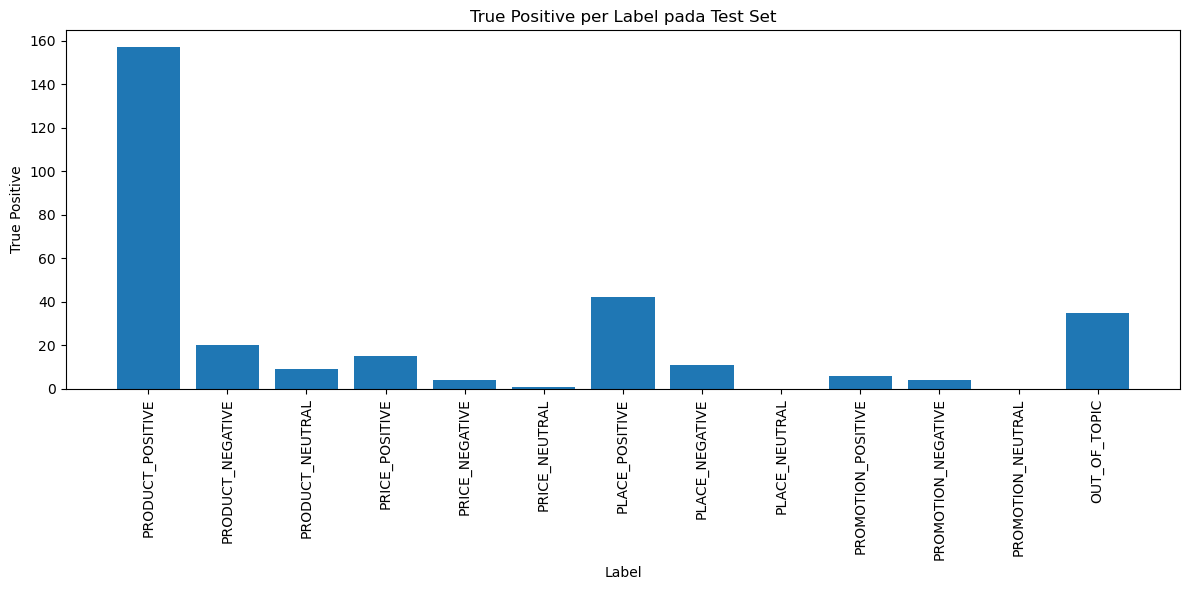

In [63]:
plt.figure(figsize=(12, 6))
plt.bar(confusion_df["label"], confusion_df["TP"])
plt.xticks(rotation=90)
plt.xlabel("Label")
plt.ylabel("True Positive")
plt.title("True Positive per Label pada Test Set")
plt.tight_layout()
plt.show()

### Prediksi Test Set ke DataFrame

In [64]:
y_test_pred_df = pd.DataFrame(
    y_test_pred,
    columns=MULTILABEL_COLUMNS
)

test_result_df = test_df[["text"]].copy()

test_result_df["true_labels"] = y_test.apply(
    lambda row: [
        label for label in MULTILABEL_COLUMNS
        if row[label] == 1
    ],
    axis=1
)

test_result_df["predicted_labels"] = y_test_pred_df.apply(
    lambda row: [
        label for label in MULTILABEL_COLUMNS
        if row[label] == 1
    ],
    axis=1
)

test_result_df["is_exact_match"] = test_result_df.apply(
    lambda row: set(row["true_labels"]) == set(row["predicted_labels"]),
    axis=1
)

test_result_df.head()

,text,true_labels,predicted_labels,is_exact_match
0,"baksonya enak, tempatnya ok, servicenya juaraa...","[PRODUCT_POSITIVE, PLACE_POSITIVE, OUT_OF_TOPIC]","[PRODUCT_POSITIVE, PRICE_POSITIVE, PLACE_POSIT...",False
1,"baksonya enak dan lezat, pelayanan cepat dan r...","[PRODUCT_POSITIVE, PLACE_POSITIVE, OUT_OF_TOPIC]","[PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_P...",False
2,"rasa bakso mantap dan enak, pelayanan sangat baik","[PRODUCT_POSITIVE, PROMOTION_POSITIVE]","[PRODUCT_POSITIVE, OUT_OF_TOPIC]",False
3,Baksonya sangat enakkk saya sudah beberapa kal...,[PRODUCT_POSITIVE],"[PRODUCT_POSITIVE, PROMOTION_POSITIVE, OUT_OF_...",False
4,"Oke, tp bakso bakarnya kurang cocok dilidahku ...","[PRODUCT_NEGATIVE, PLACE_POSITIVE]","[PRODUCT_POSITIVE, PRODUCT_NEGATIVE, PLACE_POS...",False


### Error Analysis

In [65]:
print("Jumlah prediksi benar persis:")
print(test_result_df["is_exact_match"].value_counts())

wrong_predictions = test_result_df[
    test_result_df["is_exact_match"] == False
].copy()

correct_predictions = test_result_df[
    test_result_df["is_exact_match"] == True
].copy()

print("Jumlah salah:", len(wrong_predictions))
print("Jumlah benar:", len(correct_predictions))

wrong_predictions.head(10)

Jumlah prediksi benar persis:
is_exact_match
False    141
True      70
Name: count, dtype: int64
Jumlah salah: 141
Jumlah benar: 70


,text,true_labels,predicted_labels,is_exact_match
0,"baksonya enak, tempatnya ok, servicenya juaraa...","[PRODUCT_POSITIVE, PLACE_POSITIVE, OUT_OF_TOPIC]","[PRODUCT_POSITIVE, PRICE_POSITIVE, PLACE_POSIT...",False
1,"baksonya enak dan lezat, pelayanan cepat dan r...","[PRODUCT_POSITIVE, PLACE_POSITIVE, OUT_OF_TOPIC]","[PRODUCT_POSITIVE, PLACE_POSITIVE, PROMOTION_P...",False
2,"rasa bakso mantap dan enak, pelayanan sangat baik","[PRODUCT_POSITIVE, PROMOTION_POSITIVE]","[PRODUCT_POSITIVE, OUT_OF_TOPIC]",False
3,Baksonya sangat enakkk saya sudah beberapa kal...,[PRODUCT_POSITIVE],"[PRODUCT_POSITIVE, PROMOTION_POSITIVE, OUT_OF_...",False
4,"Oke, tp bakso bakarnya kurang cocok dilidahku ...","[PRODUCT_NEGATIVE, PLACE_POSITIVE]","[PRODUCT_POSITIVE, PRODUCT_NEGATIVE, PLACE_POS...",False
5,"Baso nya enak, tempat nya luas, service cepat,...","[PRODUCT_POSITIVE, PRODUCT_NEGATIVE, PLACE_POS...","[PRODUCT_POSITIVE, PRODUCT_NEGATIVE, PLACE_POS...",False
6,"Kacau. Udah sejam-an gak dateng dateng, padaha...",[OUT_OF_TOPIC],"[PROMOTION_NEGATIVE, OUT_OF_TOPIC]",False
7,Salah satu resto bakso yang terkenal di Yogyak...,"[PRODUCT_POSITIVE, PRICE_POSITIVE, PLACE_POSIT...","[PRODUCT_POSITIVE, PRICE_POSITIVE, PLACE_POSIT...",False
8,tempat makan yang sangat enak rekomem,[PLACE_POSITIVE],"[PRODUCT_POSITIVE, PROMOTION_POSITIVE]",False
9,"Baksonya enak, banyak variasi nya, harganya ju...","[PRODUCT_POSITIVE, PRICE_POSITIVE, PLACE_POSIT...","[PRODUCT_POSITIVE, PRICE_POSITIVE, PLACE_POSIT...",False


### Simpan Hasil Prediksi dan Error Analysis

In [66]:
test_result_df.to_csv(
    "../models/Kelp4_multilabel_test_predictions.csv",
    index=False
)

wrong_predictions.to_csv(
    "../models/Kelp4_multilabel_wrong_predictions.csv",
    index=False
)

correct_predictions.to_csv(
    "../models/Kelp4_multilabel_correct_predictions.csv",
    index=False
)

print("Hasil prediksi dan error analysis berhasil disimpan.")

Hasil prediksi dan error analysis berhasil disimpan.


In [67]:
from IPython.display import Markdown

Markdown("""
### Analisis Kesalahan Multilabel

Berdasarkan hasil evaluasi pada test set, model multilabel sudah mampu memprediksi label dominan seperti PRODUCT_POSITIVE dan PLACE_POSITIVE dengan cukup baik. Namun, model masih mengalami kesalahan pada beberapa kasus.

Pola kesalahan yang ditemukan:
1. Model cenderung memprediksi label dominan seperti PRODUCT_POSITIVE.
2. Model masih kesulitan pada label minoritas seperti PRICE_NEUTRAL, PLACE_NEUTRAL, dan PROMOTION_NEUTRAL.
3. Model dapat menghasilkan label tambahan yang tidak ada pada ground truth.
4. Kalimat negasi seperti "tidak enak" dapat membingungkan model karena kata "enak" memiliki sinyal positif.
5. Beberapa review memiliki lebih dari satu aspek sehingga exact match menjadi lebih sulit dicapai.

Perbaikan yang dilakukan:
1. Menggunakan class_weight="balanced" pada Logistic Regression dan Linear SVM.
2. Menggunakan threshold tuning berdasarkan validation set.
3. Menambahkan negation-aware preprocessing.
4. Pada deployment, post-processing digunakan untuk mengurangi prediksi kontradiktif berdasarkan error analysis.
""")


### Analisis Kesalahan Multilabel

Berdasarkan hasil evaluasi pada test set, model multilabel sudah mampu memprediksi label dominan seperti PRODUCT_POSITIVE dan PLACE_POSITIVE dengan cukup baik. Namun, model masih mengalami kesalahan pada beberapa kasus.

Pola kesalahan yang ditemukan:
1. Model cenderung memprediksi label dominan seperti PRODUCT_POSITIVE.
2. Model masih kesulitan pada label minoritas seperti PRICE_NEUTRAL, PLACE_NEUTRAL, dan PROMOTION_NEUTRAL.
3. Model dapat menghasilkan label tambahan yang tidak ada pada ground truth.
4. Kalimat negasi seperti "tidak enak" dapat membingungkan model karena kata "enak" memiliki sinyal positif.
5. Beberapa review memiliki lebih dari satu aspek sehingga exact match menjadi lebih sulit dicapai.

Perbaikan yang dilakukan:
1. Menggunakan class_weight="balanced" pada Logistic Regression dan Linear SVM.
2. Menggunakan threshold tuning berdasarkan validation set.
3. Menambahkan negation-aware preprocessing.
4. Pada deployment, post-processing digunakan untuk mengurangi prediksi kontradiktif berdasarkan error analysis.


### Threshold Tuning Multilabel

In [68]:
if hasattr(best_multilabel_model, "predict_proba"):
    y_val_proba = best_multilabel_model.predict_proba(X_val)

    thresholds = {}

    for i, label in enumerate(MULTILABEL_COLUMNS):
        best_threshold = 0.5
        best_f1 = 0

        for threshold in np.arange(0.1, 0.91, 0.05):
            y_pred_label = (y_val_proba[:, i] >= threshold).astype(int)
            f1 = f1_score(
                y_val[label],
                y_pred_label,
                zero_division=0
            )

            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold

        thresholds[label] = round(float(best_threshold), 2)

else:
    thresholds = {label: 0.5 for label in MULTILABEL_COLUMNS}

thresholds

{'PRODUCT_POSITIVE': 0.35,
 'PRODUCT_NEGATIVE': 0.7,
 'PRODUCT_NEUTRAL': 0.55,
 'PRICE_POSITIVE': 0.35,
 'PRICE_NEGATIVE': 0.25,
 'PRICE_NEUTRAL': 0.1,
 'PLACE_POSITIVE': 0.5,
 'PLACE_NEGATIVE': 0.6,
 'PLACE_NEUTRAL': 0.5,
 'PROMOTION_POSITIVE': 0.35,
 'PROMOTION_NEGATIVE': 0.3,
 'PROMOTION_NEUTRAL': 0.15,
 'OUT_OF_TOPIC': 0.3}

### Simpan Best Model, Label, dan Threshold

In [69]:
joblib.dump(
    best_multilabel_model,
    "../models/Kelp4_best_multilabel_model.pkl"
)

joblib.dump(
    MULTILABEL_COLUMNS,
    "../models/Kelp4_multilabel_labels.pkl"
)

joblib.dump(
    thresholds,
    "../models/Kelp4_multilabel_thresholds.pkl"
)

print("Best multilabel model berhasil disimpan.")
print("Label multilabel berhasil disimpan.")
print("Threshold multilabel berhasil disimpan.")

Best multilabel model berhasil disimpan.
Label multilabel berhasil disimpan.
Threshold multilabel berhasil disimpan.


### Tes Prediksi Manual

In [70]:
sample_text = "Baksonya tidak enak"
sample_clean = clean_text(sample_text)

print("Teks asli:", sample_text)
print("Teks clean:", sample_clean)

if hasattr(best_multilabel_model, "predict_proba"):
    sample_proba = best_multilabel_model.predict_proba([sample_clean])[0]
else:
    sample_proba = best_multilabel_model.predict([sample_clean])[0].astype(float)

sample_result = pd.DataFrame({
    "label": MULTILABEL_COLUMNS,
    "confidence": sample_proba,
    "threshold": [
        thresholds.get(label, 0.5)
        for label in MULTILABEL_COLUMNS
    ]
})

sample_result["prediksi"] = sample_result.apply(
    lambda row: 1 if row["confidence"] >= row["threshold"] else 0,
    axis=1
)

sample_result.sort_values(
    by="confidence",
    ascending=False
)

Teks asli: Baksonya tidak enak
Teks clean: baksonya tidak tidak_enak


,label,confidence,threshold,prediksi
0,PRODUCT_POSITIVE,0.842528,0.35,1
7,PLACE_NEGATIVE,0.522855,0.60,0
12,OUT_OF_TOPIC,0.407298,0.30,1
10,PROMOTION_NEGATIVE,0.337328,0.30,1
6,PLACE_POSITIVE,0.303619,0.50,0
9,PROMOTION_POSITIVE,0.228403,0.35,0
4,PRICE_NEGATIVE,0.225694,0.25,0
1,PRODUCT_NEGATIVE,0.171798,0.70,0
2,PRODUCT_NEUTRAL,0.116979,0.55,0
3,PRICE_POSITIVE,0.101509,0.35,0
